In [2]:
env_USE_GOOGLE_COLAB = False
env_USE_NVIDIA = False
env_CONTENT_PATH = ""
env_TIF_PATH = ""
env_WANT_NGROK = False
env_Latest_RUN_ID = 0
import sys
from settings import load_BatGutsSettings, show_python_version, corr2, get_most_recent_subdirectory, get_most_recent_numeric_subdirectory
from settings import run_mlflow_until_q
show_python_version()

S = load_BatGutsSettings()
env_CONTENT_PATH = S.zContentPath
env_TIF_PATH = S.zTifPath
env_USE_GOOGLE_COLAB = S.useGoogleColab
env_USE_NVIDIA = S.useNvidia
env_MODEL_FILENAME = S.zModelFilename
env_FULL_MODEL_PATH = env_CONTENT_PATH + "/" + env_MODEL_FILENAME


Python version: 3.10.12
Loading settings from /home/elliot/BatGutsImageClassification2/jupyternb/.env
my_CONTENT_PATH=/home/elliot/BatGutsImageClassification2/
my_TIF_PATH=/mnt/d/


In [ ]:
#this is for setting the model to use CPU only
#if you want to try and use CUDA thats fine just dont run this cell
#i will warn you though it is really annoying

import tensorflow as tf
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
# Disable all GPUs
tf.config.set_visible_devices([], 'GPU')

# Verify that only the CPU is being used
print("Available devices:", tf.config.list_physical_devices('CPU'))



2025-02-06 12:06:56.611547: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-06 12:06:57.077209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-06 12:06:57.224846: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-06 12:06:57.258522: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-06 12:06:57.550436: I tensorflow/core/platform/cpu_feature_guar

Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


I0000 00:00:1738861623.758334  415936 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1738861624.212448  415936 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1738861624.212537  415936 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
import numpy as np
from matplotlib import pyplot as plt
import tifffile as tiff
from pyngrok import ngrok
import numpy as np
from PIL import Image as im
from PIL import  ImageOps
import numpy as np
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
from tensorflow.python.keras.utils.data_utils import Sequence
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline
import mlflow
''' 
this cell sets up a clean environment for MLflow tracking:
It removes any existing MLflow runs directory (if it exists).
It creates a fresh directory for new MLflow runs.
It configures MLflow to use this new directory for tracking experiments and runs.
This approach ensures that MLflow starts with a clean slate, which can be useful for avoiding conflicts with 
previous runs or for maintaining a consistent environment across different executions of a machine learning workflow.
'''
zUrl = env_CONTENT_PATH + "/mlruns/"
if os.path.exists(zUrl):
    shutil.rmtree(zUrl)    #r removes the entire directory tree 
    print(f"Deleted directory: {zUrl}")
os.makedirs(zUrl, exist_ok=True)
mlflow.set_tracking_uri(zUrl)   # sets the tracking URI for MLflow to the newly created directory 
EXPERIMENT_NAME = "Batguts-Insects_vs_plants_Siamese_256"
EXPERIMENT_ID = mlflow.create_experiment(EXPERIMENT_NAME)
import seaborn as sns
import cv2
import time
import os
import glob

Deleted directory: /home/elliot/BatGutsImageClassification2//mlruns/


In [5]:
''' 
Standardizes each image in the list:
It subtracts the mean (mean_img)
Then divides by the standard deviation (std_img)
This process centers the pixel values around 0 and scales them to have unit variance.
'''
def standardize_image(img_list):
  mean_img = np.mean(img_list,axis=0)  # calculates the mean value across all images in the list
  std_img = np.std(img_list,axis=0)   # calculates the standard deviation across all images in the list,
  img_list = (img_list - mean_img)/std_img
  return img_list


In [6]:
''' 
This function loads images from a specific category and create scorresponding image and label lists.
'''
def train_imgs(img_list=list(),category=None,label_list=None):
  if len(img_list)==0 and label_list is  None :
    img_list=[]
  else :
    img_list =img_list
  for main_path in glob.glob( env_CONTENT_PATH + "/images/Bats_mixed_images_RGB_256/"+ str(category)+"/"):
      paths=glob.glob(os.path.join(main_path,"*.jpeg"))
  print('{} Images Count: {}'.format(category,len(paths)))
  for image_path in paths:
        image = cv2.imread(image_path)
        img_list.append(image)
        label_list.append(category)
  return img_list,label_list

In [7]:
#prepare training data
train_imgs_list = list()
labels_list =list()
# train_imgs_list,labels_list=train_imgs(train_imgs_list,'Blood',labels_list)
train_imgs_list,labels_list=train_imgs(train_imgs_list,'Insects',labels_list)

train_imgs_list,labels_list=train_imgs(train_imgs_list,'Plants',labels_list)


Insects Images Count: 168
Plants Images Count: 241


In [8]:
from sklearn.preprocessing import LabelEncoder
labels_list= LabelEncoder().fit_transform(labels_list)
from collections import Counter
Counter(labels_list)

Counter({1: 241, 0: 168})

In [9]:
#Shuffle the data
import random

temp = list(zip(train_imgs_list, labels_list))
random.shuffle(temp)
train_imgs_list,labels_list = zip(*temp)
train_imgs_list,labels_list = list(train_imgs_list), list(labels_list)

In [10]:
'''
This code performs two important preprocessing steps on a list of images, typically in preparation for training a 
machine learning model, particularly a neural network.  

First it converts train_imgs_list to a NumPy array with data type float32.
Then it Divides the array by 255.0.
This normalizes the pixel values of the images to a range between 0 and 1.
Normalization is important because:
  It helps achieve faster convergence during model training.
  It ensures all features (pixel values) are on a similar scale, which is crucial for many machine learning algorithms.
  
Then it calls the standardize_image function on the normalized image array.
Standardization typically involves subtracting the mean and dividing by the standard deviation.
This centers the data around zero and scales it to have unit variance.
Benefits of standardization include:
  Making training less sensitive to the scale of features.
  Improving the numerical stability of some machine learning algorithms.
'''
X = np.array(train_imgs_list,np.float32)/255.0
X = standardize_image(X)

In [11]:
''' 
This cell converts a Python list called labels_list into a NumPy array

Converting labels_list to a NumPy array makes it more efficient and provides 
access to a wide range of functionalities for numerical and data manipulation tasks. This step is 
often a part of data preprocessing in machine learning workflows.
'''
labels_list = np.array(labels_list)

In [12]:
num_classes = 2
def one_hot_labels(img_list,classes):


  label_numeric = {k:v for v,k in enumerate(set(img_list))}
  target_values = [label_numeric[k] for k in img_list]
  target_values = np.array(target_values)
  target_values = to_categorical(target_values,num_classes=num_classes)
  return target_values

labels_list = one_hot_labels(labels_list,num_classes)

In [13]:

''' 
This cell is using the train_test_split function from scikit-learn to split the 
dataset into training, validation, and test sets. 
'''
# Splitting the data into train and validation set
from sklearn.model_selection import train_test_split
print("Shape of X:", X.shape)
print("Shape of labels_list:", labels_list.shape)
# X, labels_list = X[:100], labels_list[:100]
X_train,x_test,Y_train,y_test = train_test_split(X,labels_list ,test_size=0.2,random_state=1,stratify=labels_list)#test_size=0.1
x_train,x_valid,y_train,y_valid = train_test_split(X_train,Y_train,test_size=0.2,random_state=1,stratify=Y_train)#test_size=0.1

Shape of X: (409, 256, 256, 3)
Shape of labels_list: (409, 2)


In [14]:
# Data Augumentation
train_datagen = ImageDataGenerator(
        rotation_range=10, # rotation
        width_shift_range=0.2, # horizontal shift
        height_shift_range=0.2, # vertical shift
        zoom_range=0.2, # zoom
        horizontal_flip=True, # horizontal flip
        brightness_range=[0.2,1.2],# brightness
        fill_mode='nearest')
train_datagen.fit(X)


In [15]:

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam

# Define the input shape
input_shape = (256, 256, 3)
base_model = ResNet50(weights=None, include_top=False, input_shape=input_shape)
x = GlobalAveragePooling2D()(base_model.output)
# x = Flatten()(base_model.output)
# x = Dense(256, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x) #so we get 2 output classes#will probably need another one later

model = Model(inputs=base_model.input, outputs=predictions)

# Print a summary of the model architecture.
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 23,538,690 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [16]:
# Compiling Model
optimizer = Adam(learning_rate=1e-3) #1e-5
model.compile(loss='binary_crossentropy', #categorical_crossentropy
              optimizer=optimizer,
              metrics=['accuracy'])
# Defining callback Methods
n_epoch = 10 #60

early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1,
                           mode='auto', restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5,
                             verbose=1, mode='auto')
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


Number of unique classes in y_train: 2
Number of unique classes in y_valid: 2
Number of unique classes in y_test: 2
Epoch 1/10


/home/elliot/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1738861667.342243  416093 service.cc:146] XLA service 0x7fbf940b87f0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738861667.347497  416093 service.cc:154]   StreamExecutor device (0): Host, Default Version
2025-02-06 12:07:48.433777: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738861705.025028  416093 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/17 ━━━━━━━━━━━━━━━━━━━━ 303s 14s/step - accuracy: 0.5382 - loss: 2.0612 - val_accuracy: 0.5909 - val_loss: 837.1270 - learning_rate: 0.0010
Epoch 2/10


2025-02-06 12:12:17.187111: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 533ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5909 - val_loss: 837.1270 - learning_rate: 0.0010
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 169s 10s/step - accuracy: 0.5453 - loss: 0.8344 - val_accuracy: 0.5909 - val_loss: 27.4806 - learning_rate: 0.0010
Epoch 4/10


2025-02-06 12:15:15.713614: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 294ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5909 - val_loss: 27.4806 - learning_rate: 0.0010
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 160s 9s/step - accuracy: 0.5894 - loss: 0.7422 - val_accuracy: 0.5000 - val_loss: 2.2566 - learning_rate: 0.0010
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 286ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5000 - val_loss: 2.2566 - learning_rate: 0.0010
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 155s 9s/step - accuracy: 0.5418 - loss: 0.7055 - val_accuracy: 0.5303 - val_loss: 0.7219 - learning_rate: 0.0010
Epoch 8/10


2025-02-06 12:20:40.095735: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5303 - val_loss: 0.7219 - learning_rate: 0.0010
Epoch 9/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 146s 8s/step - accuracy: 0.5296 - loss: 0.6800 - val_accuracy: 0.5909 - val_loss: 0.6985 - learning_rate: 0.0010
Epoch 10/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.5909 - val_loss: 0.6985 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 9.


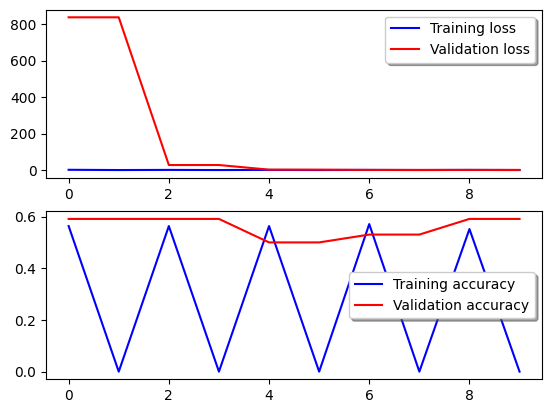

3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step


/home/elliot/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/elliot/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/elliot/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     Insects       0.00      0.00      0.00        34
      Plants       0.59      1.00      0.74        48

    accuracy                           0.59        82
   macro avg       0.29      0.50      0.37        82
weighted avg       0.34      0.59      0.43        82



ValueError: Classification metrics can't handle a mix of multilabel-indicator and binary targets

In [17]:
''' 
This cell This code performs a series of tasks to train a machine learning model using different batch 
sizes, evaluate its performance, plot the results, 
make predictions, and log the results using MLflow. 
'''
print("Number of unique classes in y_train:", len(np.unique(y_train)))
print("Number of unique classes in y_valid:", len(np.unique(y_valid)))
print("Number of unique classes in y_test:", len(np.unique(y_test)))
for idx, batch_size in enumerate([16]): #8, 16, 32, 64, 128
    history = model.fit(
        train_datagen.flow(x_train, y_train, batch_size=batch_size),
        epochs=n_epoch,
        callbacks=[reduce_lr, early_stop],
        validation_data=(x_valid, y_valid),
        # steps_per_epoch=len(x_train) // batch_size  # Adjusted to match the batch size,
        steps_per_epoch=int(np.ceil(len(x_train) / batch_size))  # Adjusted to match the batch size,

    )
    
    # Plotting the results on Graph
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(history.history['loss'], color='b', label="Training loss")
    ax[0].plot(history.history['val_loss'], color='r', label="Validation loss")
    ax[0].legend(loc='best', shadow=True)
    
    ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
    ax[1].plot(history.history['val_accuracy'], color='r', label="Validation accuracy")
    ax[1].legend(loc='best', shadow=True)
    
    plt.show()  # Ensure the plot displays within each iteration

    # Predictions
    predictions_model = model.predict(x_test)
    predictions_model_max = np.argmax(predictions_model, axis=1)
    num_classes = len(np.unique(y_test))  # Ensure correct number of classes
    y_test_int = np.argmax(y_test, axis=1)
    print(classification_report(y_test_int, predictions_model_max, target_names=['Insects', 'Plants']))
    # predictions_onehot = to_categorical(predictions_model_max, num_classes=num_classes)
    # accuracy = accuracy_score(y_test, predictions_onehot)
    accuracy = accuracy_score(y_test, y_test_int)

    
    # print(classification_report(y_test, predictions_onehot, target_names=['Insects', 'Plants']))

    # Start MLflow
    RUN_NAME = f"run_{idx}"
    with mlflow.start_run(experiment_id=EXPERIMENT_ID, run_name=RUN_NAME) as run:
        # Retrieve run id
        RUN_ID = run.info.run_id
        env_Latest_RUN_ID = RUN_ID
        print(f"MLflow run ID: {RUN_ID}")
        # Track parameters
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("epochs", 60)
        mlflow.log_param("image_size", 256)

        # Track model
        mlflow.sklearn.log_model(model, "Bat_guts_IVP_classifier")

        # Track confusion matrix results
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric('Weighted Precision', precision_score(y_test, predictions_onehot, average='weighted'))
        mlflow.log_metric('Weighted Recall', recall_score(y_test, predictions_onehot, average='weighted'))
        mlflow.log_metric('Weighted F1-score', f1_score(y_test, predictions_onehot, average='weighted'))


